In [122]:
TICKERS = ["2330.TW"]
START_TIME = "2020-01-01"
INTERVAL = "1d"
FEATURES = ["Close"]
SEQ_LEN = 60

In [123]:
import yfinance as yf


df = yf.download(TICKERS, start=START_TIME, end="2025-12-31", interval=INTERVAL)
if df is None or df.empty:
    raise ValueError("Failed to download train data")
data = df[FEATURES].to_numpy()

print(data.shape)

[*********************100%***********************]  1 of 1 completed

(1456, 1)


In [124]:
split = int(len(data) * 0.8)
train, test = data[:split], data[split:]

print(train.shape, test.shape)

(1164, 1) (292, 1)


In [125]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [126]:
import numpy as np


def create_sequences(data, seq_len=60, data_prev=None):
    X, y = [], []
    if data_prev is not None:
        data = np.concatenate((data_prev[-seq_len:], data))
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len : i])
        y.append(data[i, 0])
    return np.array(X), np.array(y).reshape(-1, 1)


X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN, train_scaled)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1104, 60, 1) (1104, 1)
(292, 60, 1) (292, 1)


In [127]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, LSTM, Dropout, Dense


tf.keras.backend.clear_session()

model = Sequential(
    [
        Input(shape=(SEQ_LEN, len(FEATURES))),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ]
)

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,057 (332.25 KB)

 Trainable params: 85,057 (332.25 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    ],
)

print("***** Training Completed *****")

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0268 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0036 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0028 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0026 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0025 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0021 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0029 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0021 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0022 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 10/1

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


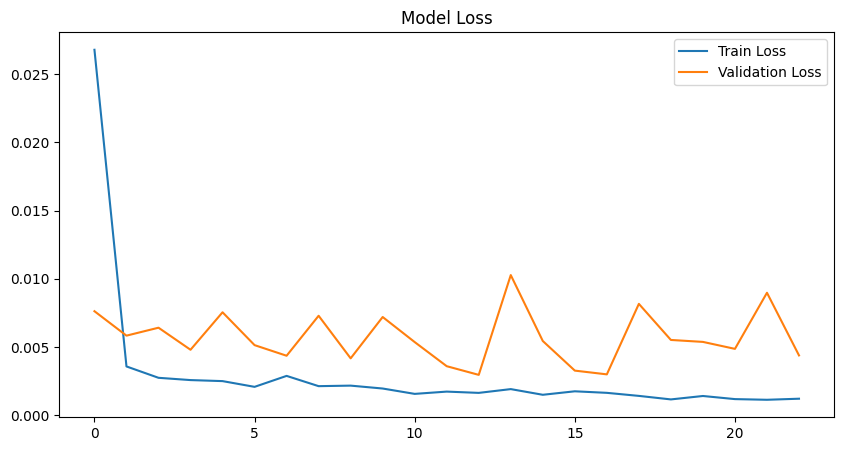

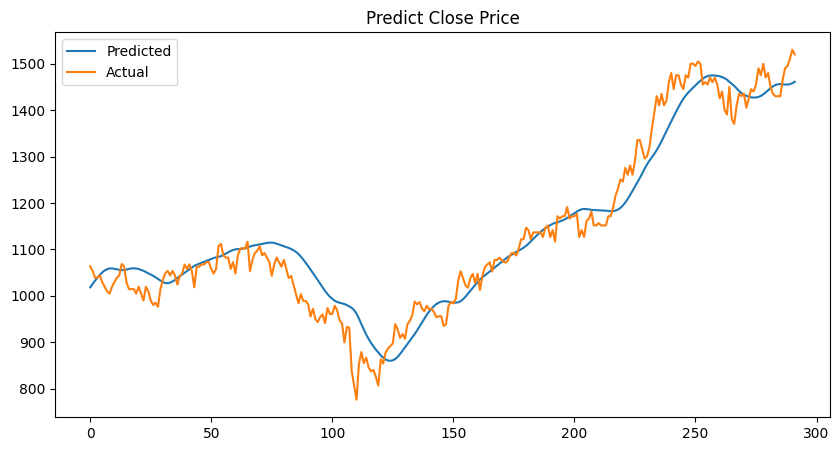

In [129]:
import matplotlib.pyplot as plt


y_pred = model.predict(X_test)
dummy_pred = np.zeros((len(y_pred), len(FEATURES)))
dummy_test = np.zeros((len(y_pred), len(FEATURES)))
dummy_pred[:, 0] = y_pred[:, 0]
dummy_test[:, 0] = y_test[:, 0]

y_pred_inv = scaler.inverse_transform(dummy_pred)[:, 0]
y_test_inv = scaler.inverse_transform(dummy_test)[:, 0]

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_pred_inv, label="Predicted")
plt.plot(y_test_inv, label="Actual")
plt.title("Predict Close Price")
plt.legend()
plt.show()